# Part 10 — Modern Deep Architectures

**PyTimeSeries user guide** · *N-HiTS / N-BEATS / PatchTST via pt.modern (neuralforecast).*

> Uses the `pytimeseries` package on the shared commodity-price dataset.

In [1]:
import warnings; warnings.simplefilter("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pytimeseries as pt
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

# Shared dataset: 356 months of global commodity prices (1992-2021)
raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]); df.index = dates
df.index.name = "date"; df = df.asfreq("MS")
y = df["Food_Price_Index"]
print("pytimeseries", pt.__version__, "| series:", list(df.columns))

pytimeseries 0.5.0 | series: ['Urea_Price', 'MP_Price', 'TSP_Price', 'Maize_Price', 'Rice_Price', 'Wheat_Price', 'Food_Price_Index', 'Energy_Price_Index', 'VIX_Index']


`pt.modern` wraps state-of-the-art architectures. We fit one small N-HiTS; `NBEATS` and `PatchTST` share the identical API.

2026-09-18 12:25:24,923	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2026-09-18 12:25:25,367	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


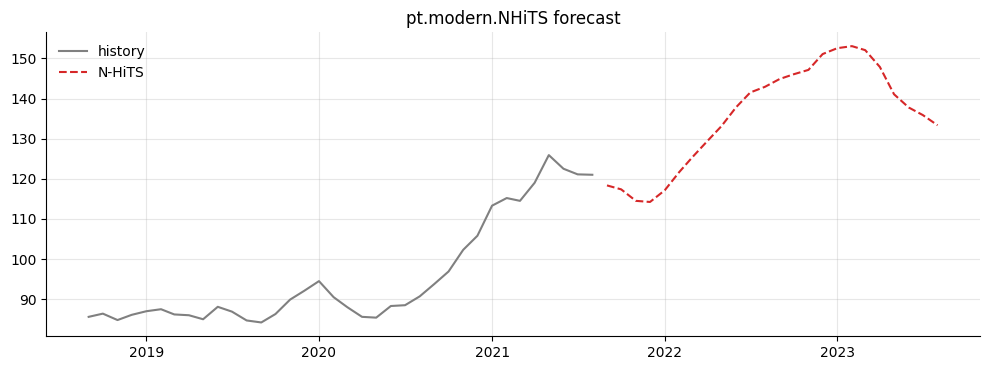

In [2]:
m = pt.modern.NHiTS(horizon=24, input_size=36, max_steps=60).fit(y)
fc = m.predict(24)
fig, ax = plt.subplots()
ax.plot(y.index[-36:], y.iloc[-36:], color='0.5', label='history')
ax.plot(fc.index, fc, 'C3--', label='N-HiTS')
ax.set_title('pt.modern.NHiTS forecast'); ax.legend(frameon=False); plt.tight_layout(); plt.show()

**Takeaway.** SOTA models are one import away and are best trained **globally** on many series (Part 8 pattern) — where they excel.